In [1]:
%%writefile gpu_image_processing.cu
// Copyright 2026 Yuvraj Verma
//
// Licensed under the MIT License.
//
// GPU Image Processing Pipeline
// Batch-processes images through a 4-stage CUDA kernel pipeline:
//   1. RGB to Grayscale  2. Gaussian Blur  3. Sobel Edge Detection  4. Threshold
//
// Usage:
//   ./imgpipeline --num_images 200 --width 256 --height 256 --threshold 50
//   ./imgpipeline --help

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>

// ---------------------------------------------------------------------------
// CUDA error checking macro — aborts on any CUDA API failure
// ---------------------------------------------------------------------------
#define CUDA_CHECK(call)                                                    \
  do {                                                                      \
    cudaError_t err = (call);                                               \
    if (err != cudaSuccess) {                                               \
      fprintf(stderr, "CUDA error at %s:%d — %s\n",                        \
              __FILE__, __LINE__, cudaGetErrorString(err));                  \
      exit(EXIT_FAILURE);                                                   \
    }                                                                       \
  } while (0)

// ---------------------------------------------------------------------------
// Configuration defaults (overridable via CLI)
// ---------------------------------------------------------------------------
static int kNumImages   = 200;
static int kImgWidth    = 256;
static int kImgHeight   = 256;
static int kThreshold   = 50;
static int kBlockSize   = 16;
static int kVerbose     = 0;
static const char* kOutputDir = "sample_output";

// ---------------------------------------------------------------------------
// CLI argument parsing
// ---------------------------------------------------------------------------
void PrintUsage(const char* prog) {
  printf("Usage: %s [options]\n", prog);
  printf("Options:\n");
  printf("  --num_images N   Number of images to process (default: 200)\n");
  printf("  --width W        Image width in pixels (default: 256)\n");
  printf("  --height H       Image height in pixels (default: 256)\n");
  printf("  --threshold T    Binary threshold value 0-255 (default: 50)\n");
  printf("  --output DIR     Output directory for sample images (default: sample_output)\n");
  printf("  --verbose        Print per-image timing\n");
  printf("  --help           Show this message\n");
}

int ParseArgs(int argc, char** argv) {
  for (int i = 1; i < argc; i++) {
    if (strcmp(argv[i], "--help") == 0) {
      PrintUsage(argv[0]);
      return 1;
    } else if (strcmp(argv[i], "--num_images") == 0 && i + 1 < argc) {
      kNumImages = atoi(argv[++i]);
    } else if (strcmp(argv[i], "--width") == 0 && i + 1 < argc) {
      kImgWidth = atoi(argv[++i]);
    } else if (strcmp(argv[i], "--height") == 0 && i + 1 < argc) {
      kImgHeight = atoi(argv[++i]);
    } else if (strcmp(argv[i], "--threshold") == 0 && i + 1 < argc) {
      kThreshold = atoi(argv[++i]);
    } else if (strcmp(argv[i], "--output") == 0 && i + 1 < argc) {
      kOutputDir = argv[++i];
    } else if (strcmp(argv[i], "--verbose") == 0) {
      kVerbose = 1;
    } else {
      printf("Unknown option: %s\n", argv[i]);
      PrintUsage(argv[0]);
      return 1;
    }
  }
  return 0;
}

// ===========================================================================
// CUDA Kernel 1: RGB to Grayscale
//
// Converts a 3-channel RGB image to single-channel grayscale using the
// standard luminance formula: Y = 0.299*R + 0.587*G + 0.114*B
// Each CUDA thread processes one pixel.
// ===========================================================================
__global__ void GrayscaleKernel(const unsigned char* rgb,
                                unsigned char* gray,
                                int width, int height) {
  int x = blockIdx.x * blockDim.x + threadIdx.x;
  int y = blockIdx.y * blockDim.y + threadIdx.y;
  if (x >= width || y >= height) return;

  int idx = y * width + x;
  int rgb_idx = idx * 3;
  gray[idx] = (unsigned char)(0.299f * rgb[rgb_idx]
                            + 0.587f * rgb[rgb_idx + 1]
                            + 0.114f * rgb[rgb_idx + 2]);
}

// ===========================================================================
// CUDA Kernel 2: Gaussian Blur (5x5)
//
// Applies a 5x5 Gaussian convolution to smooth the image and reduce noise.
// The kernel weights approximate a Gaussian with sigma ~1.0.
// Border pixels use clamped (repeated-edge) boundary conditions.
// ===========================================================================
__global__ void GaussianBlurKernel(const unsigned char* input,
                                   unsigned char* output,
                                   int width, int height) {
  int x = blockIdx.x * blockDim.x + threadIdx.x;
  int y = blockIdx.y * blockDim.y + threadIdx.y;
  if (x >= width || y >= height) return;

  // 5x5 Gaussian weights (sum = 273)
  const int kGauss[5][5] = {
    {1,  4,  7,  4, 1},
    {4, 16, 26, 16, 4},
    {7, 26, 41, 26, 7},
    {4, 16, 26, 16, 4},
    {1,  4,  7,  4, 1}
  };

  int sum = 0;
  for (int ky = -2; ky <= 2; ky++) {
    for (int kx = -2; kx <= 2; kx++) {
      int px = min(max(x + kx, 0), width - 1);
      int py = min(max(y + ky, 0), height - 1);
      sum += input[py * width + px] * kGauss[ky + 2][kx + 2];
    }
  }
  output[y * width + x] = (unsigned char)(sum / 273);
}

// ===========================================================================
// CUDA Kernel 3: Sobel Edge Detection
//
// Computes gradient magnitude using 3x3 Sobel operators:
//   Gx = [-1 0 +1; -2 0 +2; -1 0 +1]
//   Gy = [-1 -2 -1;  0  0  0; +1 +2 +1]
//   Magnitude = sqrt(Gx^2 + Gy^2), clamped to [0, 255]
// ===========================================================================
__global__ void SobelEdgeKernel(const unsigned char* input,
                                unsigned char* output,
                                int width, int height) {
  int x = blockIdx.x * blockDim.x + threadIdx.x;
  int y = blockIdx.y * blockDim.y + threadIdx.y;
  if (x >= width || y >= height) return;

  if (x == 0 || x == width - 1 || y == 0 || y == height - 1) {
    output[y * width + x] = 0;
    return;
  }

  int gx = -1 * input[(y-1)*width + (x-1)] + 1 * input[(y-1)*width + (x+1)]
           -2 * input[(y  )*width + (x-1)] + 2 * input[(y  )*width + (x+1)]
           -1 * input[(y+1)*width + (x-1)] + 1 * input[(y+1)*width + (x+1)];

  int gy = -1 * input[(y-1)*width + (x-1)] - 2 * input[(y-1)*width + x]
           -1 * input[(y-1)*width + (x+1)]
           +1 * input[(y+1)*width + (x-1)] + 2 * input[(y+1)*width + x]
           +1 * input[(y+1)*width + (x+1)];

  int mag = (int)sqrtf((float)(gx * gx + gy * gy));
  output[y * width + x] = (unsigned char)(mag > 255 ? 255 : mag);
}

// ===========================================================================
// CUDA Kernel 4: Binary Thresholding
//
// Converts a grayscale image to binary (black/white).
// Pixels >= threshold become 255 (white), others become 0 (black).
// ===========================================================================
__global__ void ThresholdKernel(const unsigned char* input,
                                unsigned char* output,
                                int width, int height,
                                unsigned char thresh) {
  int x = blockIdx.x * blockDim.x + threadIdx.x;
  int y = blockIdx.y * blockDim.y + threadIdx.y;
  if (x >= width || y >= height) return;

  int idx = y * width + x;
  output[idx] = (input[idx] >= thresh) ? 255 : 0;
}

// ---------------------------------------------------------------------------
// CPU reference implementations (for speedup comparison)
// ---------------------------------------------------------------------------
void CpuGrayscale(const unsigned char* rgb, unsigned char* gray,
                  int w, int h) {
  for (int i = 0; i < w * h; i++)
    gray[i] = (unsigned char)(0.299f*rgb[i*3] + 0.587f*rgb[i*3+1]
                            + 0.114f*rgb[i*3+2]);
}

void CpuGaussianBlur(const unsigned char* in, unsigned char* out,
                     int w, int h) {
  const int g[5][5] = {
    {1,4,7,4,1},{4,16,26,16,4},{7,26,41,26,7},{4,16,26,16,4},{1,4,7,4,1}
  };
  for (int y = 0; y < h; y++)
    for (int x = 0; x < w; x++) {
      int s = 0;
      for (int ky = -2; ky <= 2; ky++)
        for (int kx = -2; kx <= 2; kx++) {
          int px = x+kx < 0 ? 0 : (x+kx >= w ? w-1 : x+kx);
          int py = y+ky < 0 ? 0 : (y+ky >= h ? h-1 : y+ky);
          s += in[py*w+px] * g[ky+2][kx+2];
        }
      out[y*w+x] = (unsigned char)(s / 273);
    }
}

void CpuSobel(const unsigned char* in, unsigned char* out, int w, int h) {
  for (int y = 0; y < h; y++)
    for (int x = 0; x < w; x++) {
      if (x == 0 || x == w-1 || y == 0 || y == h-1) { out[y*w+x]=0; continue; }
      int gx = -in[(y-1)*w+(x-1)] + in[(y-1)*w+(x+1)]
               -2*in[y*w+(x-1)]   + 2*in[y*w+(x+1)]
               -in[(y+1)*w+(x-1)] + in[(y+1)*w+(x+1)];
      int gy = -in[(y-1)*w+(x-1)] - 2*in[(y-1)*w+x] - in[(y-1)*w+(x+1)]
               +in[(y+1)*w+(x-1)] + 2*in[(y+1)*w+x] + in[(y+1)*w+(x+1)];
      int m = (int)sqrtf((float)(gx*gx + gy*gy));
      out[y*w+x] = (unsigned char)(m > 255 ? 255 : m);
    }
}

void CpuThreshold(const unsigned char* in, unsigned char* out,
                  int w, int h, unsigned char t) {
  for (int i = 0; i < w * h; i++)
    out[i] = (in[i] >= t) ? 255 : 0;
}

// ---------------------------------------------------------------------------
// Synthetic test image generator
// ---------------------------------------------------------------------------
void GenerateTestImage(unsigned char* rgb, int w, int h, int seed) {
  srand(seed);
  for (int y = 0; y < h; y++)
    for (int x = 0; x < w; x++) {
      int i = (y * w + x) * 3;
      rgb[i]   = (unsigned char)((x * 200 / w + seed * 13) % 256);
      rgb[i+1] = (unsigned char)((y * 180 / h + seed * 7) % 256);
      rgb[i+2] = (unsigned char)(((x+y) * 150 / (w+h) + seed * 19) % 256);
    }
  // Random circles
  for (int s = 0; s < 3 + seed % 5; s++) {
    int cx = rand() % w, cy = rand() % h, r = 15 + rand() % 40;
    unsigned char cr = rand()%256, cg = rand()%256, cb = rand()%256;
    for (int y = cy-r; y <= cy+r; y++)
      for (int x = cx-r; x <= cx+r; x++) {
        if (x<0||x>=w||y<0||y>=h) continue;
        if ((x-cx)*(x-cx)+(y-cy)*(y-cy) <= r*r) {
          int i = (y*w+x)*3; rgb[i]=cr; rgb[i+1]=cg; rgb[i+2]=cb;
        }
      }
  }
  // Random rectangles
  for (int s = 0; s < 2 + seed % 3; s++) {
    int rx = rand()%(w-40), ry = rand()%(h-40);
    int rw = 20+rand()%60, rh = 20+rand()%60;
    unsigned char cr = rand()%256, cg = rand()%256, cb = rand()%256;
    for (int y = ry; y < ry+rh && y < h; y++)
      for (int x = rx; x < rx+rw && x < w; x++) {
        int i = (y*w+x)*3; rgb[i]=cr; rgb[i+1]=cg; rgb[i+2]=cb;
      }
  }
}

// ---------------------------------------------------------------------------
// File I/O: PGM (grayscale) and PPM (color) image formats
// ---------------------------------------------------------------------------
void SavePgm(const char* path, const unsigned char* data, int w, int h) {
  FILE* f = fopen(path, "wb");
  if (!f) { printf("ERROR: cannot write %s\n", path); return; }
  fprintf(f, "P5\n%d %d\n255\n", w, h);
  fwrite(data, 1, w * h, f);
  fclose(f);
  printf("  Saved: %s\n", path);
}

void SavePpm(const char* path, const unsigned char* data, int w, int h) {
  FILE* f = fopen(path, "wb");
  if (!f) { printf("ERROR: cannot write %s\n", path); return; }
  fprintf(f, "P6\n%d %d\n255\n", w, h);
  fwrite(data, 1, w * h * 3, f);
  fclose(f);
  printf("  Saved: %s\n", path);
}

// ---------------------------------------------------------------------------
// Main
// ---------------------------------------------------------------------------
int main(int argc, char** argv) {
  if (ParseArgs(argc, argv)) return 0;

  int W = kImgWidth, H = kImgHeight;
  int rgb_bytes  = W * H * 3;
  int gray_bytes = W * H;

  // -- Print configuration --
  cudaDeviceProp prop;
  cudaGetDeviceProperties(&prop, 0);

  printf("==========================================================\n");
  printf("  CUDA Image Processing Pipeline\n");
  printf("==========================================================\n");
  printf("  GPU            : %s\n", prop.name);
  printf("  SMs            : %d\n", prop.multiProcessorCount);
  printf("  Images         : %d  (%d x %d RGB)\n", kNumImages, W, H);
  printf("  Threshold      : %d\n", kThreshold);
  printf("  Total data     : %.1f MB\n",
         (float)kNumImages * rgb_bytes / (1024.0f * 1024.0f));
  printf("  Pipeline       : Grayscale -> GaussBlur -> Sobel -> Threshold\n");
  printf("  Output dir     : %s/\n", kOutputDir);
  printf("==========================================================\n\n");

  // -- Allocate host memory --
  unsigned char* h_rgb    = (unsigned char*)malloc(rgb_bytes);
  unsigned char* h_gray   = (unsigned char*)malloc(gray_bytes);
  unsigned char* h_blur   = (unsigned char*)malloc(gray_bytes);
  unsigned char* h_edge   = (unsigned char*)malloc(gray_bytes);
  unsigned char* h_thresh = (unsigned char*)malloc(gray_bytes);

  unsigned char* c_gray   = (unsigned char*)malloc(gray_bytes);
  unsigned char* c_blur   = (unsigned char*)malloc(gray_bytes);
  unsigned char* c_edge   = (unsigned char*)malloc(gray_bytes);
  unsigned char* c_thresh = (unsigned char*)malloc(gray_bytes);

  // -- Allocate device memory --
  unsigned char *d_rgb, *d_gray, *d_blur, *d_edge, *d_thresh;
  CUDA_CHECK(cudaMalloc(&d_rgb,    rgb_bytes));
  CUDA_CHECK(cudaMalloc(&d_gray,   gray_bytes));
  CUDA_CHECK(cudaMalloc(&d_blur,   gray_bytes));
  CUDA_CHECK(cudaMalloc(&d_edge,   gray_bytes));
  CUDA_CHECK(cudaMalloc(&d_thresh, gray_bytes));

  dim3 block(kBlockSize, kBlockSize);
  dim3 grid((W + kBlockSize - 1) / kBlockSize,
            (H + kBlockSize - 1) / kBlockSize);

  // ======================= GPU Batch Processing ==========================
  printf("[GPU] Processing %d images through 4-kernel pipeline...\n", kNumImages);

  cudaEvent_t t_start, t_stop;
  cudaEventCreate(&t_start);
  cudaEventCreate(&t_stop);
  cudaEventRecord(t_start);

  for (int i = 0; i < kNumImages; i++) {
    GenerateTestImage(h_rgb, W, H, i + 1);

    cudaMemcpy(d_rgb, h_rgb, rgb_bytes, cudaMemcpyHostToDevice);

    GrayscaleKernel<<<grid, block>>>(d_rgb, d_gray, W, H);
    GaussianBlurKernel<<<grid, block>>>(d_gray, d_blur, W, H);
    SobelEdgeKernel<<<grid, block>>>(d_blur, d_edge, W, H);
    ThresholdKernel<<<grid, block>>>(d_edge, d_thresh, W, H,
                                     (unsigned char)kThreshold);

    cudaMemcpy(h_thresh, d_thresh, gray_bytes, cudaMemcpyDeviceToHost);

    if (kVerbose || (i + 1) % 50 == 0 || i == 0) {
      printf("  [GPU] Image %3d / %d done\n", i + 1, kNumImages);
    }
  }

  cudaEventRecord(t_stop);
  cudaEventSynchronize(t_stop);
  float gpu_ms = 0;
  cudaEventElapsedTime(&gpu_ms, t_start, t_stop);
  printf("  [GPU] Complete: %.2f ms total (%.2f ms/image)\n\n",
         gpu_ms, gpu_ms / kNumImages);

  // ======================= CPU Batch Processing ==========================
  printf("[CPU] Processing %d images (reference)...\n", kNumImages);
  clock_t cpu_t0 = clock();

  for (int i = 0; i < kNumImages; i++) {
    GenerateTestImage(h_rgb, W, H, i + 1);
    CpuGrayscale(h_rgb, c_gray, W, H);
    CpuGaussianBlur(c_gray, c_blur, W, H);
    CpuSobel(c_blur, c_edge, W, H);
    CpuThreshold(c_edge, c_thresh, W, H, (unsigned char)kThreshold);

    if (kVerbose || (i + 1) % 50 == 0 || i == 0) {
      printf("  [CPU] Image %3d / %d done\n", i + 1, kNumImages);
    }
  }

  double cpu_ms = 1000.0 * (clock() - cpu_t0) / CLOCKS_PER_SEC;
  printf("  [CPU] Complete: %.2f ms total (%.2f ms/image)\n\n",
         cpu_ms, cpu_ms / kNumImages);

  // ====================== Save Sample Outputs ============================
  printf("[OUTPUT] Saving pipeline stages for image #1...\n");

  GenerateTestImage(h_rgb, W, H, 1);

  // Save input
  char path[256];
  snprintf(path, sizeof(path), "%s/input_rgb.ppm", kOutputDir);
  SavePpm(path, h_rgb, W, H);

  // Run pipeline on GPU and save each stage
  cudaMemcpy(d_rgb, h_rgb, rgb_bytes, cudaMemcpyHostToDevice);

  GrayscaleKernel<<<grid, block>>>(d_rgb, d_gray, W, H);
  cudaMemcpy(h_gray, d_gray, gray_bytes, cudaMemcpyDeviceToHost);
  snprintf(path, sizeof(path), "%s/stage1_grayscale.pgm", kOutputDir);
  SavePgm(path, h_gray, W, H);

  GaussianBlurKernel<<<grid, block>>>(d_gray, d_blur, W, H);
  cudaMemcpy(h_blur, d_blur, gray_bytes, cudaMemcpyDeviceToHost);
  snprintf(path, sizeof(path), "%s/stage2_gaussian_blur.pgm", kOutputDir);
  SavePgm(path, h_blur, W, H);

  SobelEdgeKernel<<<grid, block>>>(d_blur, d_edge, W, H);
  cudaMemcpy(h_edge, d_edge, gray_bytes, cudaMemcpyDeviceToHost);
  snprintf(path, sizeof(path), "%s/stage3_sobel_edges.pgm", kOutputDir);
  SavePgm(path, h_edge, W, H);

  ThresholdKernel<<<grid, block>>>(d_edge, d_thresh, W, H,
                                   (unsigned char)kThreshold);
  cudaMemcpy(h_thresh, d_thresh, gray_bytes, cudaMemcpyDeviceToHost);
  snprintf(path, sizeof(path), "%s/stage4_threshold.pgm", kOutputDir);
  SavePgm(path, h_thresh, W, H);

  // ======================== Results Summary ==============================
  float speedup = (float)cpu_ms / gpu_ms;

  printf("\n==========================================================\n");
  printf("  Results Summary\n");
  printf("==========================================================\n");
  printf("  Images processed : %d  (%d x %d)\n", kNumImages, W, H);
  printf("  Kernels per image: 4  (Grayscale, Blur, Sobel, Threshold)\n");
  printf("  Total kernels    : %d\n", kNumImages * 4);
  printf("  Threads per image: %d  (%dx%d grid of %dx%d blocks)\n",
         grid.x * grid.y * block.x * block.y,
         grid.x, grid.y, block.x, block.y);
  printf("----------------------------------------------------------\n");
  printf("  GPU total time   : %10.2f ms\n", gpu_ms);
  printf("  CPU total time   : %10.2f ms\n", cpu_ms);
  printf("  GPU per image    : %10.2f ms\n", gpu_ms / kNumImages);
  printf("  CPU per image    : %10.2f ms\n", cpu_ms / kNumImages);
  printf("  Speedup          : %.1fx\n", speedup);
  printf("==========================================================\n");
  printf("  Output artifacts in: %s/\n", kOutputDir);
  printf("==========================================================\n");

  // ======================== CSV Benchmark Export ==========================
  snprintf(path, sizeof(path), "%s/benchmark_results.csv", kOutputDir);
  FILE* csv = fopen(path, "w");
  if (csv) {
    fprintf(csv, "metric,value\n");
    fprintf(csv, "gpu_name,%s\n", prop.name);
    fprintf(csv, "num_images,%d\n", kNumImages);
    fprintf(csv, "image_width,%d\n", W);
    fprintf(csv, "image_height,%d\n", H);
    fprintf(csv, "pixels_per_image,%d\n", W * H);
    fprintf(csv, "total_kernels,%d\n", kNumImages * 4);
    fprintf(csv, "threshold,%d\n", kThreshold);
    fprintf(csv, "gpu_total_ms,%.2f\n", gpu_ms);
    fprintf(csv, "cpu_total_ms,%.2f\n", cpu_ms);
    fprintf(csv, "gpu_per_image_ms,%.2f\n", gpu_ms / kNumImages);
    fprintf(csv, "cpu_per_image_ms,%.2f\n", cpu_ms / kNumImages);
    fprintf(csv, "speedup_x,%.1f\n", speedup);
    fprintf(csv, "total_data_mb,%.1f\n",
            (float)kNumImages * rgb_bytes / (1024.0f * 1024.0f));
    fclose(csv);
    printf("  Saved: %s\n", path);
  }

  // -- Cleanup --
  free(h_rgb); free(h_gray); free(h_blur); free(h_edge); free(h_thresh);
  free(c_gray); free(c_blur); free(c_edge); free(c_thresh);
  CUDA_CHECK(cudaFree(d_rgb)); CUDA_CHECK(cudaFree(d_gray));
  CUDA_CHECK(cudaFree(d_blur)); CUDA_CHECK(cudaFree(d_edge));
  CUDA_CHECK(cudaFree(d_thresh));
  CUDA_CHECK(cudaEventDestroy(t_start));
  CUDA_CHECK(cudaEventDestroy(t_stop));

  return 0;
}


Writing gpu_image_processing.cu


In [2]:
!mkdir -p sample_output
!nvcc -O2 -o imgpipeline gpu_image_processing.cu
!./imgpipeline --num_images 200 --width 256 --height 256 --threshold 50


nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
  CUDA Image Processing Pipeline
  GPU            : Tesla T4
  SMs            : 40
  Images         : 200  (256 x 256 RGB)
  Threshold      : 50
  Total data     : 37.5 MB
  Pipeline       : Grayscale -> GaussBlur -> Sobel -> Threshold
  Output dir     : sample_output/

[GPU] Processing 200 images through 4-kernel pipeline...
  [GPU] Image   1 / 200 done
  [GPU] Image  50 / 200 done
  [GPU] Image 100 / 200 done
  [GPU] Image 150 / 200 done
  [GPU] Image 200 / 200 done
  [GPU] Complete: 393.15 ms total (1.97 ms/image)

[CPU] Processing 200 images (reference)...
  [CPU] Image   1 / 200 done
  [CPU] Image  50 / 200 done
  [CPU] Image 100 / 200 done
  [CPU] Image 150 / 200 done
  [CPU] Image 200 / 200 done
  [CPU] Complete: 1519.25 ms total (7.60 ms/image)

[OUTPUT] Saving pipeline stages for image #1...
 

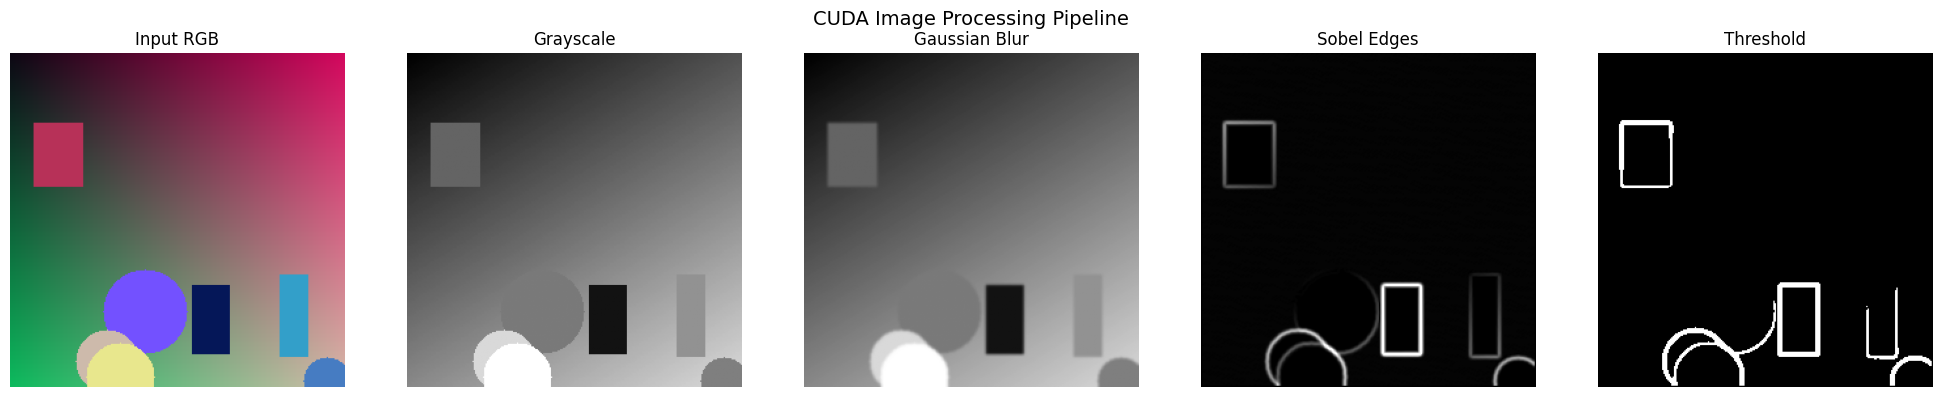

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
files = ['sample_output/input_rgb.ppm',
         'sample_output/stage1_grayscale.pgm',
         'sample_output/stage2_gaussian_blur.pgm',
         'sample_output/stage3_sobel_edges.pgm',
         'sample_output/stage4_threshold.pgm']
titles = ['Input RGB', 'Grayscale', 'Gaussian Blur', 'Sobel Edges', 'Threshold']
for ax, f, t in zip(axes, files, titles):
    ax.imshow(Image.open(f), cmap='gray')
    ax.set_title(t); ax.axis('off')
plt.suptitle('CUDA Image Processing Pipeline', fontsize=14)
plt.tight_layout()
plt.savefig('sample_output/pipeline_visualization.png', dpi=150)
plt.show()


In [4]:
import pandas as pd
df = pd.read_csv('sample_output/benchmark_results.csv')
print(df.to_string(index=False))


          metric    value
        gpu_name Tesla T4
      num_images      200
     image_width      256
    image_height      256
pixels_per_image    65536
   total_kernels      800
       threshold       50
    gpu_total_ms   393.15
    cpu_total_ms  1519.25
gpu_per_image_ms     1.97
cpu_per_image_ms     7.60
       speedup_x      3.9
   total_data_mb     37.5
